In [ ]:
#importamos las librerias necesarias al inicio del codigo.
import pandas as pd
import numpy as np

→ Leer datos desde archivos CSV, Excel y páginas web.

In [ ]:
# leer el archivo en formato .XLSX
df1_excel=pd.read_excel("clientes.xlsx")
df1_excel

,ID,Nombre,Edad,Ingresos,Ciudad,Estado Civil,Hijos,Nivel Educativo,Ocupación,Fecha Registro
0,1,Ana,25.0,1200.0,Santiago,Soltera,0.0,Universitario,Ingeniera,2023-01-10
1,2,Luis,32.0,2500.0,Concepción,Casado,2.0,Técnico,Profesor,2023-02-15
2,3,Marta,NaN,1800.0,Valparaíso,Soltera,1.0,Universitario,Abogada,2023-03-20
3,4,Pedro,40.0,100000.0,Antofagasta,Casado,3.0,Doctorado,Empresario,2023-04-05
4,5,Ana,25.0,1200.0,Santiago,Soltera,0.0,Universitario,Ingeniera,2023-01-10
5,6,Carla,29.0,3000.0,Temuco,Casada,NaN,Técnico,Enfermera,2023-05-12
6,7,Jorge,55.0,4500.0,Rancagua,Divorciado,2.0,Universitario,Contador,2023-06-18
7,8,Sofía,22.0,900.0,La Serena,Soltera,0.0,Universitario,Estudiante,2023-07-25
8,9,Tomás,35.0,20000.0,Punta Arenas,Casado,5.0,Doctorado,Médico,2023-08-30
9,10,Valeria,28.0,2800.0,Chillán,Soltera,1.0,Universitario,Diseñadora,2023-09-10


In [ ]:
# Leer el archivo .CSV.
df2_csv=pd.read_csv("compras.csv",na_values=['na'])
df2_csv

,ID,Producto,Cantidad,Precio,Fecha Compra,Método Pago,Tienda,Garantía,Vendedor,Descuento
0,1,Laptop,1.0,800,2024-01-15,Tarjeta,Falabella,Sí,Juan,0%
1,2,Celular,2.0,600,2024-02-10,Efectivo,Ripley,Sí,María,10%
2,3,Tablet,NaN,300,2024-03-05,Tarjeta,Paris,No,Pedro,5%
3,4,Consola,10.0,50000,2024-04-20,Transferencia,PC Factory,Sí,Carla,0%
4,5,Laptop,1.0,800,2024-01-15,Tarjeta,Falabella,Sí,Juan,0%
5,6,Televisor,2.0,1500,2024-05-12,Tarjeta,Lider,Sí,Jorge,15%
6,7,Monitor,1.0,200,2024-06-01,Efectivo,Hites,No,Sofía,0%
7,8,Mouse,5.0,20,2024-07-18,Tarjeta,Falabella,No,Luis,0%
8,9,Celular,50.0,100000,2024-08-25,Transferencia,Ripley,Sí,Marta,20%
9,10,Impresora,3.0,400,2024-09-10,Tarjeta,PC Factory,Sí,Tomás,5%


In [ ]:
# Leer archivo .HTML desde la URL del SII para buscar la tabla con los valores de UF
url=r"https://www.sii.cl/valores_y_fechas/uf/uf2025.htm"
df3_htm=pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})
print(f"Number of tables found: {len(df3_htm)}")


Number of tables found: 13


→ Identificar y gestionar valores nulos mediante imputación o eliminación.

In [ ]:
#   Usando la funcion info() para detectar los valores faltantes
df1_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               11 non-null     int64  
 1   Nombre           11 non-null     object 
 2   Edad             11 non-null     object 
 3   Ingresos         11 non-null     float64
 4   Ciudad           11 non-null     object 
 5   Estado Civil     11 non-null     object 
 6   Hijos            10 non-null     float64
 7   Nivel Educativo  11 non-null     object 
 8   Ocupación        11 non-null     object 
 9   Fecha Registro   11 non-null     object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1012.0+ bytes


In [ ]:
#   Rellenamos los datos faltantes con diferentes tipos, en edad usamos un "Texto", en la columna de INGRESOS usamos MEAN() para llenarnos con el promedio, mientras que en la colunma hijos usamos el ROUND() del PROMEDIO para que el numero de hijo sea un entero.
df1_excel.fillna({'Edad':"No responde",'Ingresos': df1_excel['Ingresos'].mean(), 'Hijos': round(df1_excel['Hijos'].mean()) }, inplace=True)
df1_excel

,ID,Nombre,Edad,Ingresos,Ciudad,Estado Civil,Hijos,Nivel Educativo,Ocupación,Fecha Registro
0,1,Ana,25.0,1200.0,Santiago,Soltera,0.0,Universitario,Ingeniera,2023-01-10
1,2,Luis,32.0,2500.0,Concepción,Casado,2.0,Técnico,Profesor,2023-02-15
2,3,Marta,No responde,1800.0,Valparaíso,Soltera,1.0,Universitario,Abogada,2023-03-20
3,4,Pedro,40.0,100000.0,Antofagasta,Casado,3.0,Doctorado,Empresario,2023-04-05
4,5,Ana,25.0,1200.0,Santiago,Soltera,0.0,Universitario,Ingeniera,2023-01-10
5,6,Carla,29.0,3000.0,Temuco,Casada,2.0,Técnico,Enfermera,2023-05-12
6,7,Jorge,55.0,4500.0,Rancagua,Divorciado,2.0,Universitario,Contador,2023-06-18
7,8,Sofía,22.0,900.0,La Serena,Soltera,0.0,Universitario,Estudiante,2023-07-25
8,9,Tomás,35.0,20000.0,Punta Arenas,Casado,5.0,Doctorado,Médico,2023-08-30
9,10,Valeria,28.0,2800.0,Chillán,Soltera,1.0,Universitario,Diseñadora,2023-09-10


In [ ]:
#   Usando la funcion info() para detectar los valores faltantes
df2_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            11 non-null     int64  
 1   Producto      11 non-null     object 
 2   Cantidad      9 non-null      float64
 3   Precio        11 non-null     int64  
 4   Fecha Compra  11 non-null     object 
 5   Método Pago   11 non-null     object 
 6   Tienda        11 non-null     object 
 7   Garantía      11 non-null     object 
 8   Vendedor      11 non-null     object 
 9   Descuento     11 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 1012.0+ bytes


In [ ]:
#   imputamos el los datos de los valores faltantes con la palabra "Empleado" más el departamento donde trabaja.
df1_csv['nombre'] = df1_csv['nombre'].fillna('Empleado' + " de " + df1_csv['departamento'].astype(str))
df1_csv

→ Detectar y tratar outliers aplicando técnicas estadísticas.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



<Axes: xlabel='Precio'>

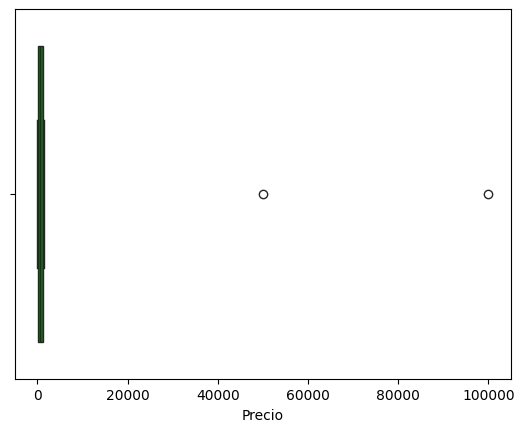

In [ ]:
# Usamos BOXPLOT para ver los OUTLIER de la columna PRECIO
sns.boxplot(x=df2_csv["Precio"], color='green')

→ Realizar tareas de Data Wrangling: ordenamiento, eliminación de
duplicados, reemplazo y transformación de valores.

In [ ]:
#   Identificar registros duplicados
df2_csv.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
#   Identificar registros duplicados
df1_excel.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
#   Transformación de valores
df2_csv['Descuento'] = df2_csv['Descuento'].str.replace('%', '').astype(float)
display(df2_csv.head())
df2_csv.info()

,ID,Producto,Cantidad,Precio,Fecha Compra,Método Pago,Tienda,Garantía,Vendedor,Descuento
0,1,Laptop,1.0,800,2024-01-15,Tarjeta,Falabella,Sí,Juan,0.0
1,2,Celular,2.0,600,2024-02-10,Efectivo,Ripley,Sí,María,10.0
2,3,Tablet,NaN,300,2024-03-05,Tarjeta,Paris,No,Pedro,5.0
3,4,Consola,10.0,50000,2024-04-20,Transferencia,PC Factory,Sí,Carla,0.0
4,5,Laptop,1.0,800,2024-01-15,Tarjeta,Falabella,Sí,Juan,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            11 non-null     int64  
 1   Producto      11 non-null     object 
 2   Cantidad      9 non-null      float64
 3   Precio        11 non-null     int64  
 4   Fecha Compra  11 non-null     object 
 5   Método Pago   11 non-null     object 
 6   Tienda        11 non-null     object 
 7   Garantía      11 non-null     object 
 8   Vendedor      11 non-null     object 
 9   Descuento     11 non-null     float64
dtypes: float64(2), int64(2), object(6)
memory usage: 1012.0+ bytes


→ Aplicar agrupamiento y pivotado de datos utilizando funciones como groupby(), pivot() y melt().

In [ ]:
#   Agrupamos por la columna OCUPACIÓN
df4=df1_excel.groupby('Ocupación').size()
df4

,0
Ocupación,
Abogada,1
Contador,1
Diseñadora,1
Empresario,1
Enfermera,1
Estudiante,1
Ingeniera,2
Jubilado,1
Médico,1


In [ ]:
#   Agrupamos por OCUPACIÓN e INGRESOS
df_group=df1_excel.groupby('Ocupación')['Ingresos'].describe()
df_group

,count,mean,std,min,25%,50%,75%,max
Ocupación,,,,,,,,
Abogada,1.0,1800.0,NaN,1800.0,1800.0,1800.0,1800.0,1800.0
Contador,1.0,4500.0,NaN,4500.0,4500.0,4500.0,4500.0,4500.0
Diseñadora,1.0,2800.0,NaN,2800.0,2800.0,2800.0,2800.0,2800.0
Empresario,1.0,100000.0,NaN,100000.0,100000.0,100000.0,100000.0,100000.0
Enfermera,1.0,3000.0,NaN,3000.0,3000.0,3000.0,3000.0,3000.0
Estudiante,1.0,900.0,NaN,900.0,900.0,900.0,900.0,900.0
Ingeniera,2.0,1200.0,0.0,1200.0,1200.0,1200.0,1200.0,1200.0
Jubilado,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Médico,1.0,20000.0,NaN,20000.0,20000.0,20000.0,20000.0,20000.0


In [ ]:
#   Creamos un DF Pivoteado para ver em una table la relación del NIVEL EDUCATIVO y la OCUPACIÓN  contra el INGRESO
df_pivot=df1_excel.pivot_table(index='Nivel Educativo',columns='Ocupación',values='Ingresos',aggfunc='sum')
df_pivot

Ocupación,Abogada,Contador,Diseñadora,Empresario,Enfermera,Estudiante,Ingeniera,Jubilado,Médico,Profesor
Nivel Educativo,,,,,,,,,,
Doctorado,NaN,NaN,NaN,100000.0,NaN,NaN,NaN,NaN,20000.0,NaN
Secundario,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
Técnico,NaN,NaN,NaN,NaN,3000.0,NaN,NaN,NaN,NaN,2500.0
Universitario,1800.0,4500.0,2800.0,NaN,NaN,900.0,2400.0,NaN,NaN,NaN


→ Combinar múltiples fuentes de datos mediante merge() y concat().


In [5]:
# Unimos los 2 DF a uno solo que contiene los clientes y las compras
df3=df1_excel.merge(df2_csv, on='ID')
df3

NameError: name 'df1_excel' is not defined

In [ ]:
# Agrupación adicional para ver el nivel de compras de acuerdo al INGRESO
df_group2=df3.groupby('Ingresos')['Precio'].describe()
df_group2

,count,mean,std,min,25%,50%,75%,max
Ingresos,,,,,,,,
900.0,1.0,20.0,NaN,20.0,20.0,20.0,20.0,20.0
1200.0,2.0,800.0,0.0,800.0,800.0,800.0,800.0,800.0
1800.0,1.0,300.0,NaN,300.0,300.0,300.0,300.0,300.0
2500.0,1.0,600.0,NaN,600.0,600.0,600.0,600.0,600.0
2800.0,1.0,400.0,NaN,400.0,400.0,400.0,400.0,400.0
3000.0,1.0,1500.0,NaN,1500.0,1500.0,1500.0,1500.0,1500.0
4500.0,1.0,200.0,NaN,200.0,200.0,200.0,200.0,200.0
20000.0,1.0,100000.0,NaN,100000.0,100000.0,100000.0,100000.0,100000.0
100000.0,1.0,50000.0,NaN,50000.0,50000.0,50000.0,50000.0,50000.0


→ Exportar el dataset final en formato CSV y Excel.

In [3]:
df3.to_csv("DF_final.csv",index=False)

NameError: name 'df3' is not defined

In [ ]:
df3.to_excel("DF_final.xlsx",index=False)

→ Incluir un script Python funcional y modularizado para ejecutar todo el
proceso.